 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submission 
Name           : Sedat Aydin                 <br>
Student Number : L00197005         <br>
Due Date       : 12/05/2026               <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI


## NLP and Vision Pipeline : High Level

This notebook follows a multimodal document processing pipeline. The same input document images are processed through image preprocessing, OCR, NLP feature extraction, rule-based classification and visual feature detection. The outputs are then combined into a final multi-modal summary.

**Pipeline flow:**

```text
INPUT DOCUMENT IMAGES
        |
        v
IMAGE PREPROCESSING (OpenCV)
- grayscale conversion
- thresholding techniques
- specific preprocessing for difficult images (receipt)
        |
        v
OCR TEXT EXTRACTION (Tesseract)
        |
        v
TEXT CLEANING AND NLP PROCESSING
- tokenisation
- stopword removal
- lemmatisation
        |
        v
TF-IDF FEATURE EXTRACTION
        |
        v
DOCUMENT CLASSIFICATION (Rule-based)
        |
        v
VISUAL FEATURE DETECTION
- contour detection
- layout region identification
        |
        v
FINAL MULTI-MODAL SUMMARY
```


## Step1: Initialisation

This section prepares the environment for the project.  
I install the required packages and import the libraries needed for OCR, NLP and computer vision.

In [1]:
# ============================================================
# Step 1a: Install required packages
# ============================================================
# I install the main libraries required for OCR, image processing and NLP tasks.

!apt-get install -y tesseract-ocr -qq

!pip install -q pytesseract
!pip install -q opencv-python-headless
!pip install -q matplotlib pillow numpy pandas nltk scikit-learn

print("Packages installed successfully.")

Packages installed successfully.


In [2]:
# ============================================================
# Step 1b: Import libraries
# ============================================================
# I import the libraries that will be used throughout the pipeline.

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import pytesseract

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

from google.colab import files

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Upload and Display Document Images

In this section, I upload the document images that will be used as the dataset.  
The same pipeline will later be applied to all images, so the system can process different document types in a consistent way.


In [3]:
# ============================================================
# Step 2a: Upload document images
# ============================================================
# I upload all document images into Colab and store their file names in a list.
# This list will allow me to apply the same pipeline to every document.

uploaded = files.upload()

image_names = list(uploaded.keys())

print("Uploaded document images:")
for image_name in image_names:
    print("-", image_name)

Saving academic_poster.jpg to academic_poster (1).jpg
Saving booking_form.jpg to booking_form (1).jpg
Saving dental_invoice.jpg to dental_invoice (1).jpg
Saving dental_statement.jpg to dental_statement (1).jpg
Saving pharmacy_receipt.jpg to pharmacy_receipt (1).jpg
Uploaded document images:
- academic_poster (1).jpg
- booking_form (1).jpg
- dental_invoice (1).jpg
- dental_statement (1).jpg
- pharmacy_receipt (1).jpg


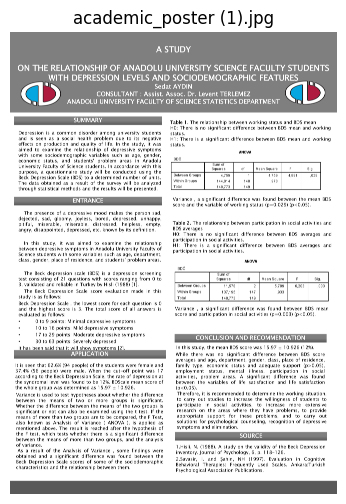

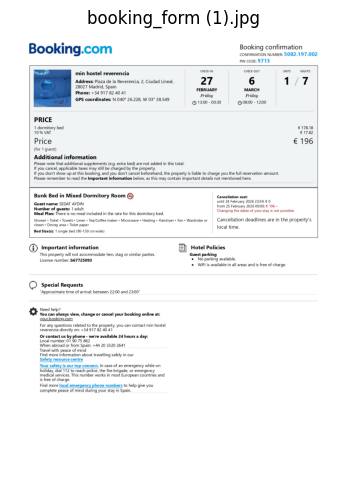

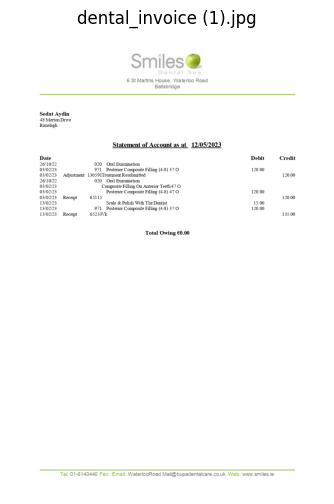

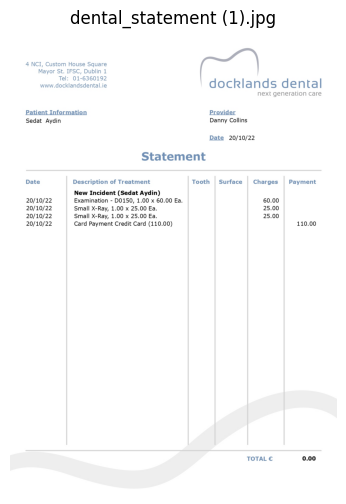

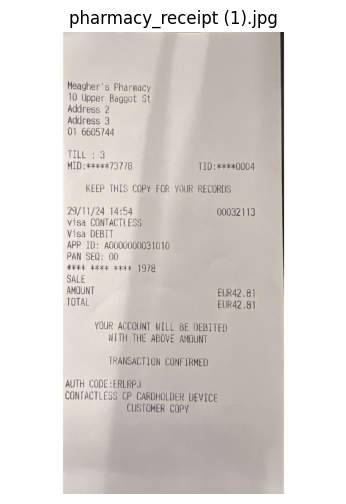

In [4]:
# ============================================================
# Step 2b: Display uploaded images
# ============================================================
# I display the uploaded images first to check that the dataset is loaded correctly.
# This is important because image quality affects OCR and computer vision results.

for image_name in image_names:
    image = Image.open(image_name)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")
    plt.show()

## Step 3: Image Preprocessing for OCR

In this section, I preprocess each document image before OCR.  
The purpose is to improve text readability by converting the image to grayscale, reducing noise, and applying thresholding.

In [5]:
# ============================================================
# Step 3a: Create image preprocessing function
# ============================================================
# I create one function so the same preprocessing steps can be applied to every document image.

def preprocess_image_for_ocr(image_path):
    image = cv2.imread(image_path)

    # Convert from BGR to RGB for correct display in matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert image to grayscale to simplify the document structure
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply blur to reduce small noise before thresholding
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Apply Otsu thresholding to create a clean black-and-white image
    threshold = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    return image_rgb, gray, threshold

In [6]:
# ============================================================
# Step 3b: Apply preprocessing to all uploaded images
# ============================================================
# I run the preprocessing function on every document and store the results in a dictionary.
# This keeps the notebook organised and avoids repeating the same code for each image.

processed_images = {}

for image_name in image_names:
    original, gray, threshold = preprocess_image_for_ocr(image_name)

    processed_images[image_name] = {
        "original": original,
        "gray": gray,
        "threshold": threshold
    }

print("Preprocessing completed for all document images.")

Preprocessing completed for all document images.


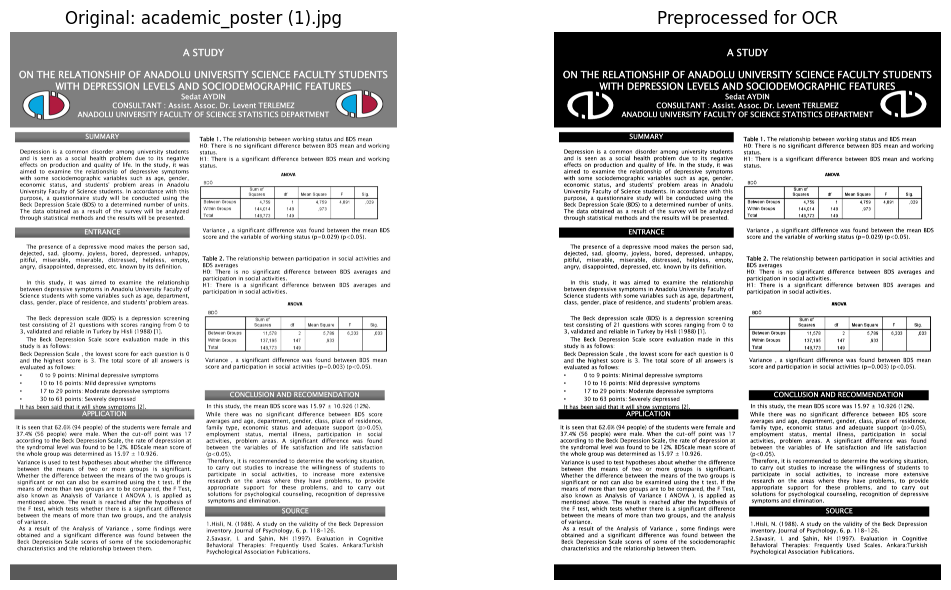

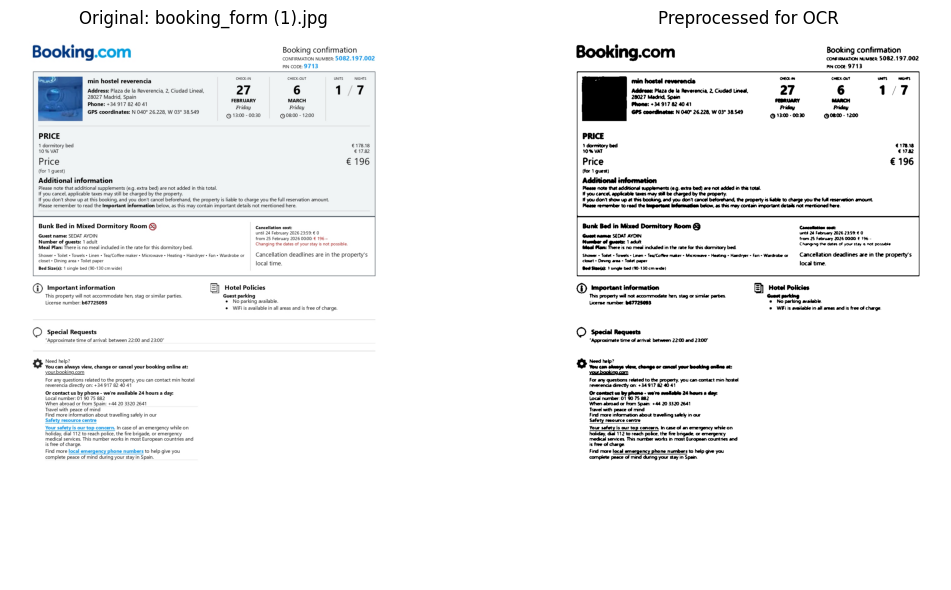

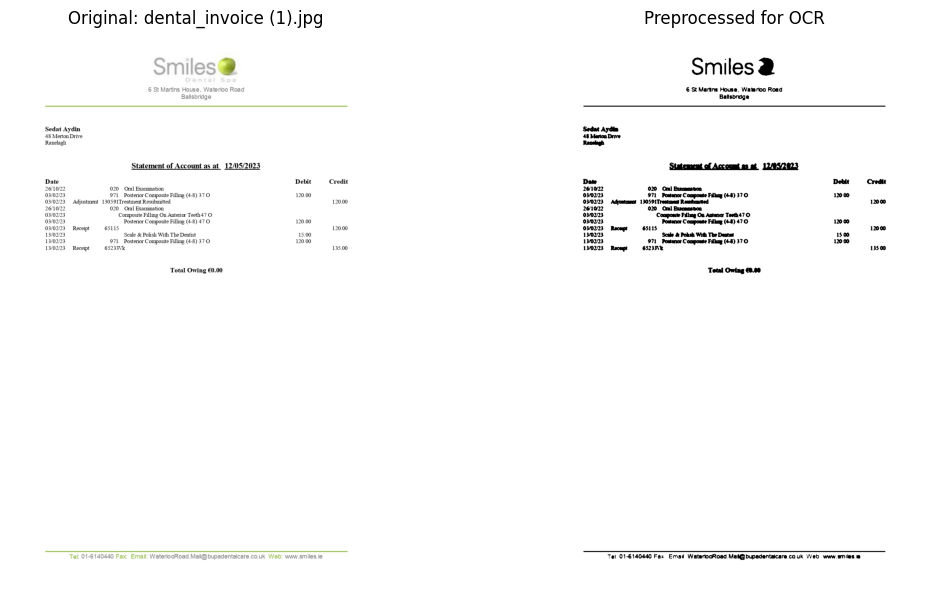

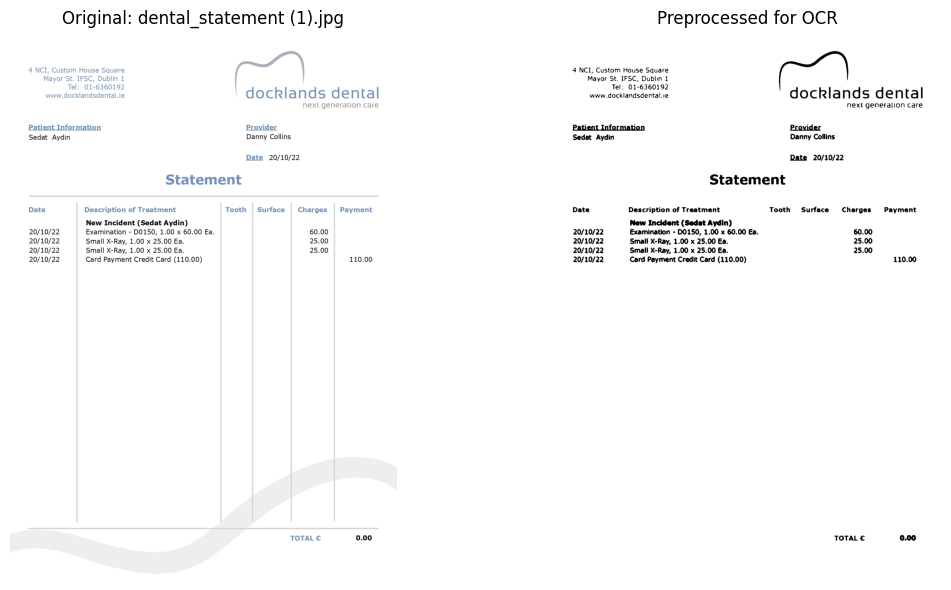

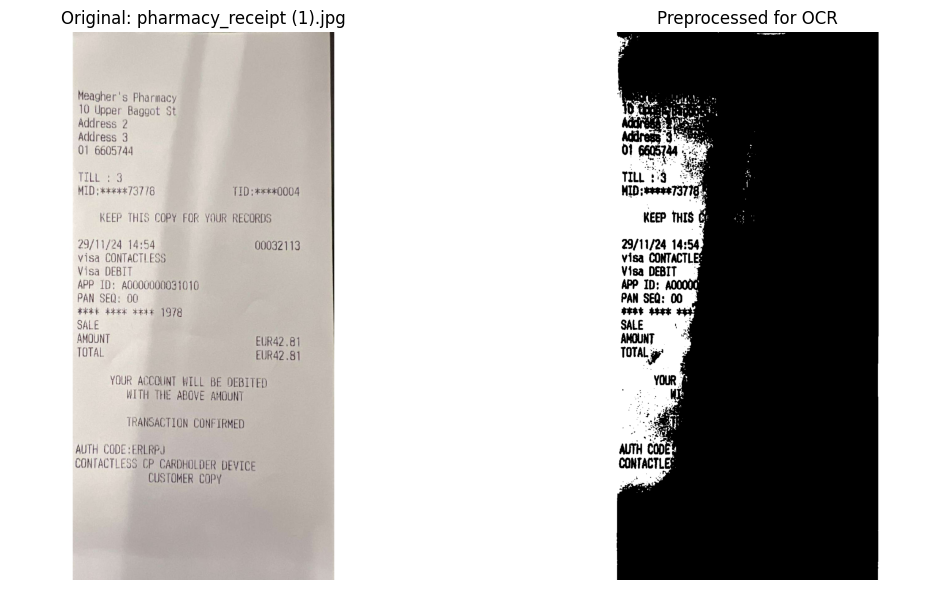

In [7]:
# ============================================================
# Step 3c: Display original and preprocessed images
# ============================================================
# I compare the original image with the thresholded image.
# This helps me check whether the preprocessing improved the document for OCR.

for image_name, images in processed_images.items():
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(images["original"])
    axes[0].set_title(f"Original: {image_name}")
    axes[0].axis("off")

    axes[1].imshow(images["threshold"], cmap="gray")
    axes[1].set_title("Preprocessed for OCR")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

### Issue with preprocessing

The thresholding method worked well for most documents.  
However, it failed on the pharmacy receipt image because the lighting conditions were uneven.

As a result, important text information was lost.

To solve this, I tested an alternative preprocessing method.

### Step 3d: Preprocessing refinement for a difficult image

After reviewing the first preprocessing results, I noticed that the standard thresholding method worked well for most documents, but it was not suitable for the pharmacy receipt.

The receipt image has uneven lighting and shadows, so the text became less clear after thresholding. Because of this, I tested a simpler preprocessing option for this document and compared the result visually.

This step was kept in the notebook to show the decision-making process and to explain why one preprocessing method may not work equally well for every document type.

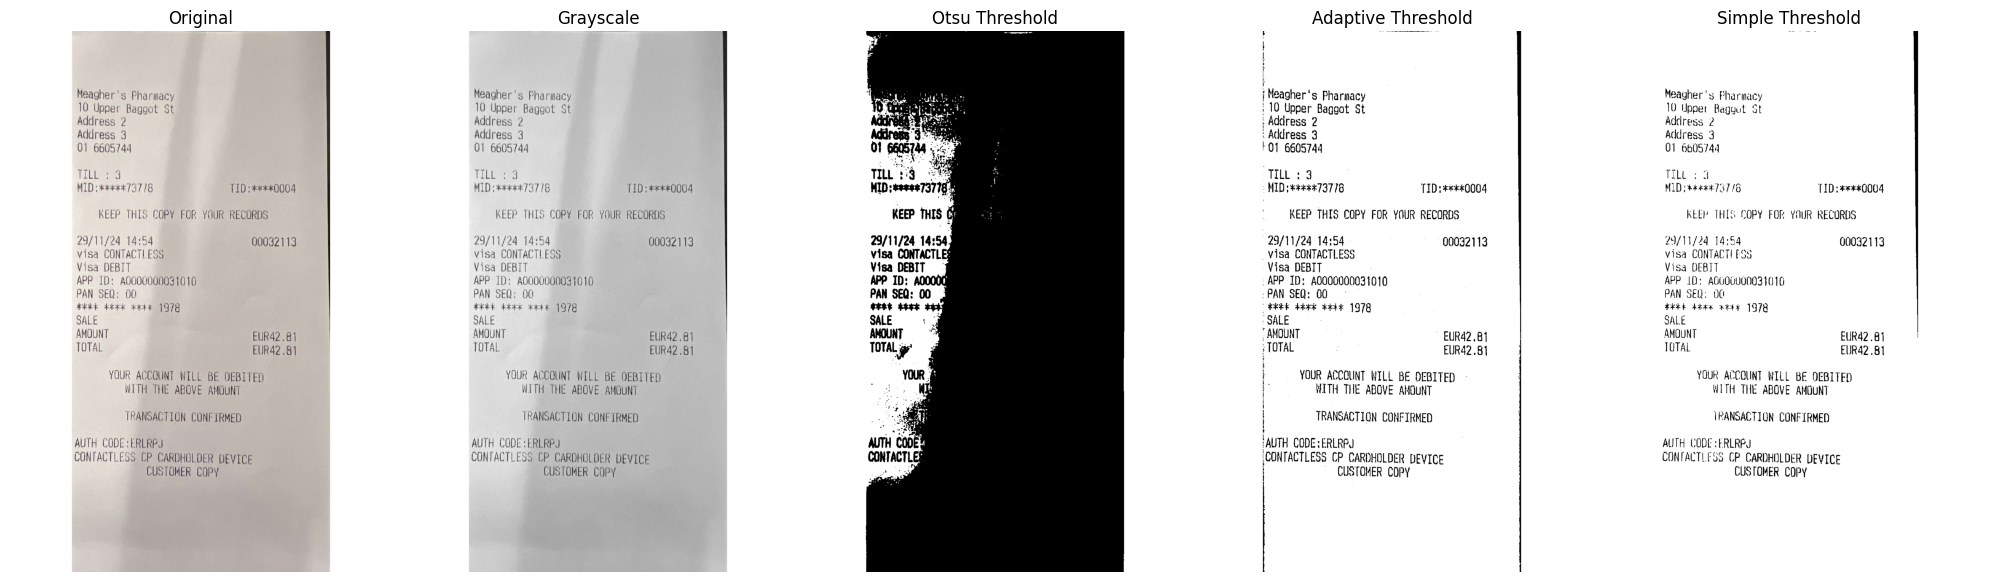

In [8]:
# ============================================================
# Step 3d: Preprocessing refinement for a difficult image
# ============================================================
# I reviewed the first preprocessing outputs and found that the pharmacy receipt needed a different approach.
# Here, I compare alternative preprocessing methods only for this difficult image.

def compare_receipt_preprocessing(image_path):
    image = cv2.imread(image_path)
    original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Method 1: Otsu thresholding
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    otsu = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    # Method 2: Adaptive thresholding
    adaptive = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 10
    )

    # Method 3: Simple binary thresholding
    simple = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)[1]

    return original, gray, otsu, adaptive, simple


receipt_image = "pharmacy_receipt.jpg"

original, gray, otsu, adaptive, simple = compare_receipt_preprocessing(receipt_image)

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

images_to_show = [original, gray, otsu, adaptive, simple]
titles = [
    "Original",
    "Grayscale",
    "Otsu Threshold",
    "Adaptive Threshold",
    "Simple Threshold"
]

for ax, img, title in zip(axes, images_to_show, titles):
    if len(img.shape) == 2:
        ax.imshow(img, cmap="gray")
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observation

The receipt image was the most difficult document due to uneven lighting and shadows.

Otsu thresholding removed too much information and failed to preserve the text.  
Adaptive thresholding introduced a high level of noise, making the image difficult to read.

The simple thresholding method produced a more balanced result and preserved most of the text.  
However, it is still not perfect and some noise remains.

This comparison shows that no single preprocessing method works equally well for all document types, and adjustments may be required depending on the image quality.

## Step 4: OCR Text Extraction

In this step, I extract text from each document image using Tesseract OCR.

The preprocessed images are used to improve the accuracy of text extraction.

In [9]:
# ============================================================
# Step 4a: OCR function
# ============================================================
# I create a function to extract text from an image using Tesseract OCR.

def extract_text(image):
    text = pytesseract.image_to_string(image)
    return text

In [10]:
# ============================================================
# Step 4b: Apply OCR to all images
# ============================================================
# I apply OCR to every document image.
# Most documents use the standard threshold image from Step 3.
# The pharmacy receipt uses the simple threshold version because Step 3d showed it gives a clearer result.

ocr_results = {}

for image_name, images in processed_images.items():

    if "pharmacy_receipt" in image_name.lower():
        # Use the simple threshold output from the comparison function in Step 3d
        _, _, _, _, ocr_image = compare_receipt_preprocessing(image_name)
    else:
        # Use standard threshold for the cleaner documents
        ocr_image = images["threshold"]

    text = pytesseract.image_to_string(ocr_image)

    ocr_results[image_name] = text

print("OCR completed for all document images.")

OCR completed for all document images.


In [11]:
# ============================================================
# Step 4c: Display OCR results
# ============================================================
# I print the extracted text for each document to evaluate the OCR performance.

for image_name, text in ocr_results.items():
    print("=" * 50)
    print(f"Document: {image_name}")
    print("=" * 50)
    print(text[:500])  # first 500 characters
    print("\n")

Document: academic_poster (1).jpg
A STUDY

ON THE RELATIONSHIP OF ANADOLU UNIVERSITY SCIENCE FACULTY STUDENTS

WITH DEPRESSION LEVELS AND SOCIODEMOGRAPHIC FEATURES
. Sedat AYDIN
CONSULTANT : Assist. Assoc. Dr. Levent TERLEMEZ
ANADOLU UNIVERSITY FACULTY OF SCIENCE STATISTICS DEPARTMENT

 

 

SUMMARY

Depression is a common disorder among university students
and is seen as a social health problem due to its negative
effects on production and quality of life. In the study, it was
aimed to examine the relationship of depressive sym


Document: booking_form (1).jpg
Booking.com Booking confirmation

CONFIRMATION NUMBER 5082.197.002

 

BN cove: 9713

min cis om creck-out wars aces

Address: Plaza de la Reverencia, 2, Ciudad Lineal, 27 6 1 / 7

28027 Madrid, Spain

FEBRUARY MARCH

Phone: «34917 82 40 41 Pridey Pridey

GPS coordinates: N 040° 26.228, W 03" 38.549 1300 - 00:30 @0%00 - 1200
PRICE
1 doreritory bed €178.18
409% VAT eye
Price € 196
(for 1 guest)

Additional information

Please not

### OCR Observation

The OCR results are generally accurate for structured and clean documents such as the poster and dental records.

The pharmacy receipt initially produced very poor results due to lighting and image quality issues.  
After applying a different preprocessing method, the OCR output improved significantly and most of the important information became readable.

This shows that preprocessing plays a critical role in OCR performance.

### OCR Evaluation

The OCR results were evaluated visually by checking whether key information such as names, dates, prices and document headings were correctly extracted.

Clean and structured documents produced more accurate text, while the receipt required additional preprocessing due to lighting issues and noise.

## Step 5: Text Preprocessing

In this step, I clean and preprocess the extracted text before applying NLP techniques.

The goal is to remove noise, standardise the text and prepare it for analysis.

In [12]:
# ============================================================
# Step 5a: Text cleaning function (updated)
# ============================================================
# I clean the OCR text while preserving important information such as numbers.

def clean_text(text):
    text = text.lower()

    # keep letters AND numbers
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text

In [13]:
# ============================================================
# Step 5b: Apply text cleaning
# ============================================================

import re
cleaned_texts = {}

for image_name, text in ocr_results.items():
    cleaned = clean_text(text)
    cleaned_texts[image_name] = cleaned

print("Text cleaning completed.")

Text cleaning completed.


## Step 6: Tokenisation, Stopword Removal and Lemmatisation

In this step, I process the cleaned OCR text using basic NLP techniques.

The text is split into tokens, common stopwords are removed, and words are lemmatised so that similar word forms are grouped together.

In [14]:
# ============================================================
# Step 6a: Create NLP preprocessing function
# ============================================================
# I create a function to tokenise the text, remove stopwords and apply lemmatisation.

def preprocess_nlp_text(text):
    tokens = word_tokenize(text)

    stop_words = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    processed_tokens = []

    for token in tokens:
        if token not in stop_words and len(token) > 2:
            lemma = lemmatizer.lemmatize(token)
            processed_tokens.append(lemma)

    return processed_tokens

In [15]:
# ============================================================
# Step 6b: Apply NLP preprocessing to all documents
# ============================================================
# I apply the same NLP preprocessing function to every document.

nlp_results = {}

for image_name, text in cleaned_texts.items():
    tokens = preprocess_nlp_text(text)
    nlp_results[image_name] = tokens

print("NLP preprocessing completed.")

NLP preprocessing completed.


In [16]:
# ============================================================
# Step 6c: Display NLP preprocessing results
# ============================================================
# I print the first tokens for each document to check that the text has been processed correctly.

for image_name, tokens in nlp_results.items():
    print("=" * 50)
    print(f"NLP tokens: {image_name}")
    print("=" * 50)
    print(tokens[:30])
    print("\n")

NLP tokens: academic_poster (1).jpg
['study', 'relationship', 'anadolu', 'university', 'science', 'faculty', 'student', 'depression', 'level', 'sociodemographic', 'feature', 'sedat', 'aydin', 'consultant', 'assist', 'assoc', 'levent', 'terlemez', 'anadolu', 'university', 'faculty', 'science', 'statistic', 'department', 'summary', 'depression', 'common', 'disorder', 'among', 'university']


NLP tokens: booking_form (1).jpg
['booking', 'com', 'booking', 'confirmation', 'confirmation', 'number', '5082', '197', '002', 'cove', '9713', 'min', 'ci', 'creck', 'war', 'ace', 'address', 'plaza', 'reverencia', 'ciudad', 'lineal', '28027', 'madrid', 'spain', 'february', 'march', 'phone', '34917', 'pridey', 'pridey']


NLP tokens: dental_invoice (1).jpg
['smile', 'martin', 'house', 'waterioo', 'road', 'balsbroge', 'sedat', 'merton', 'deve', 'ranelagh', 'statement', 'account', '2023', 'date', '261022', '020', 'oral', 'exeomnaton', '990223', '971', 'postenor', 'compoute', 'fillkng', '370', '030223', '

### NLP Observation

The NLP preprocessing step produced meaningful tokens for most documents.

For structured and text-heavy documents such as the academic poster and dental records, the extracted tokens clearly represent the main topics and content.

For the booking form and receipt, some noise is still present due to OCR errors (e.g. misspelled words). However, important keywords such as "booking", "price", "visa", and "sale" were successfully extracted.

The pharmacy receipt initially failed in earlier steps, but after improving the preprocessing, it now produces useful tokens including transactional and location-related information.

Overall, this step shows that NLP results are strongly dependent on OCR quality, and errors in OCR can propagate into later stages of the pipeline.

## Step 7: TF-IDF Feature Extraction

In this step, I use TF-IDF (Term Frequency - Inverse Document Frequency) to identify the most important words in each document.

This helps to highlight the key topics and distinguish between different document types.

In [17]:
# ============================================================
# Step 7a: Prepare documents for TF-IDF
# ============================================================
# I convert token lists back into strings because TF-IDF works on text, not tokens.

documents = []
document_names = []

for image_name, tokens in nlp_results.items():
    text = " ".join(tokens)
    documents.append(text)
    document_names.append(image_name)

print("Documents prepared for TF-IDF.")

Documents prepared for TF-IDF.


In [18]:
# ============================================================
# Step 7b: Apply TF-IDF
# ============================================================
# I calculate TF-IDF scores for all documents.

vectorizer = TfidfVectorizer(max_features=20)
tfidf_matrix = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

print("TF-IDF calculation completed.")

TF-IDF calculation completed.


In [19]:
# ============================================================
# Step 7c: Display top keywords for each document
# ============================================================
# I extract and print the top keywords based on TF-IDF scores.

for i, doc_name in enumerate(document_names):
    scores = tfidf_matrix[i].toarray()[0]

    word_scores = list(zip(feature_names, scores))
    sorted_words = sorted(word_scores, key=lambda x: x[1], reverse=True)

    print("=" * 50)
    print(f"Top keywords: {doc_name}")
    print("=" * 50)

    for word, score in sorted_words[:10]:
        if score > 0:
            print(f"{word}: {round(score, 3)}")

    print("\n")

Top keywords: academic_poster (1).jpg
mean: 0.345
bd: 0.318
difference: 0.318
significant: 0.318
depression: 0.292
score: 0.292
group: 0.212
student: 0.212
study: 0.212
beck: 0.186


Top keywords: booking_form (1).jpg
number: 0.995
total: 0.098


Top keywords: dental_invoice (1).jpg
scale: 0.861
total: 0.509


Top keywords: dental_statement (1).jpg
total: 1.0


Top keywords: pharmacy_receipt (1).jpg
total: 1.0




### TF-IDF Evaluation and Improvement

The first TF-IDF output was technically working, but the results were not very informative for some documents.

Some generic words such as "total" and "number" received very high scores. This happened because the dataset is small and these words appeared strongly in short structured documents such as receipts and forms.

To improve the feature extraction, I adjusted the TF-IDF settings by increasing the number of features, adding bigrams, and reducing the effect of overly common terms.

In [21]:
# ============================================================
# Step 7d: Improved TF-IDF feature extraction
# ============================================================
# The first TF-IDF attempt worked, but some results were too generic.
# I improve the vectorizer settings to capture more meaningful keywords and short phrases.

improved_vectorizer = TfidfVectorizer(
    max_features=50,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.8
)

improved_tfidf_matrix = improved_vectorizer.fit_transform(documents)
improved_feature_names = improved_vectorizer.get_feature_names_out()

print("Improved TF-IDF calculation completed.")

Improved TF-IDF calculation completed.


In [22]:
# ============================================================
# Step 7e: Display improved TF-IDF keywords
# ============================================================
# I display the improved TF-IDF results to check whether the keywords are more useful.

improved_tfidf_results = {}

for i, doc_name in enumerate(document_names):
    scores = improved_tfidf_matrix[i].toarray()[0]
    word_scores = list(zip(improved_feature_names, scores))
    sorted_words = sorted(word_scores, key=lambda x: x[1], reverse=True)

    top_keywords = [(word, round(score, 3)) for word, score in sorted_words[:10] if score > 0]
    improved_tfidf_results[doc_name] = top_keywords

    print("=" * 50)
    print(f"Improved top keywords: {doc_name}")
    print("=" * 50)

    for word, score in top_keywords:
        print(f"{word}: {score}")

    print("\n")

Improved top keywords: academic_poster (1).jpg
mean: 0.285
bd: 0.263
difference: 0.263
significant: 0.263
depression: 0.241
score: 0.241
significant difference: 0.241
group: 0.175
student: 0.175
study: 0.175


Improved top keywords: booking_form (1).jpg
bed: 0.507
property: 0.507
number: 0.491
booking: 0.406
charge: 0.246
area: 0.082
aydin: 0.068
date: 0.068
sedat: 0.057


Improved top keywords: dental_invoice (1).jpg
12000: 0.973
scale: 0.157
date: 0.13
sedat: 0.11


Improved top keywords: dental_statement (1).jpg
aydin: 0.54
date: 0.54
sedat: 0.454
charge: 0.325
square: 0.325


Improved top keywords: pharmacy_receipt (1).jpg




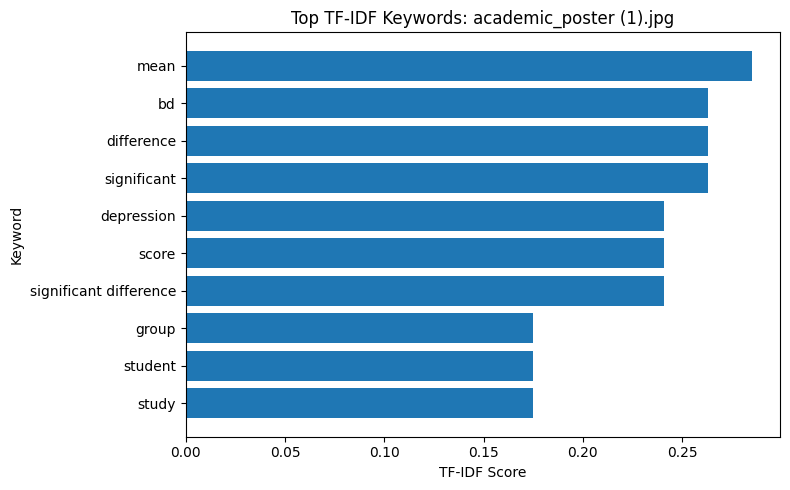

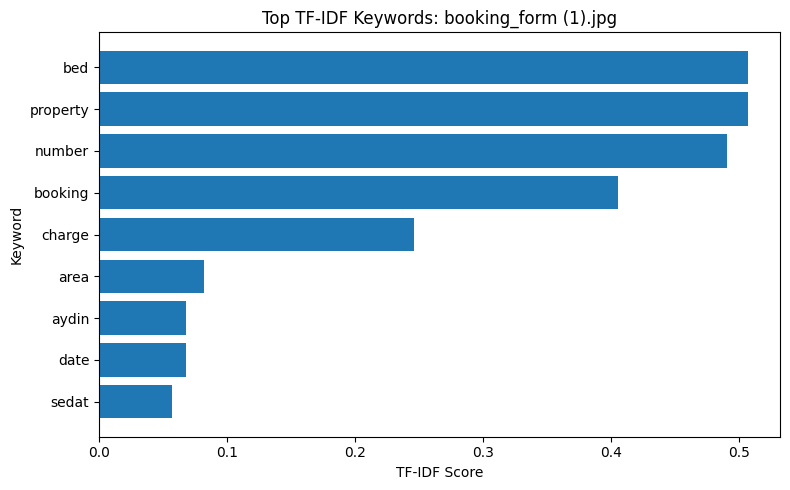

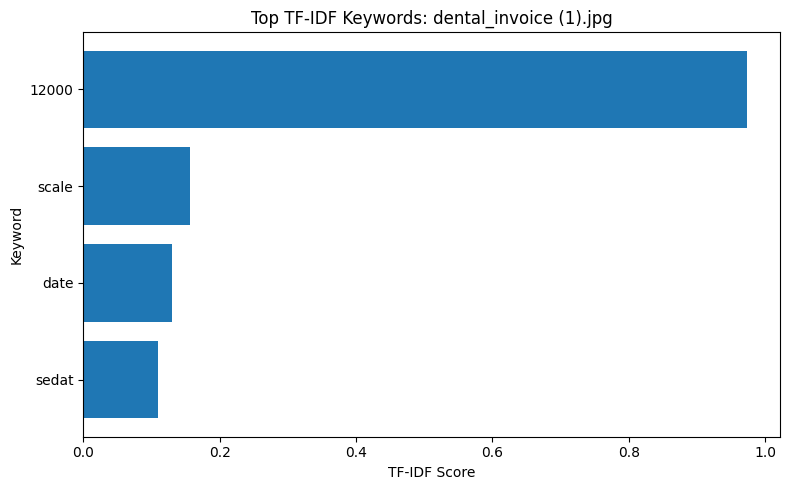

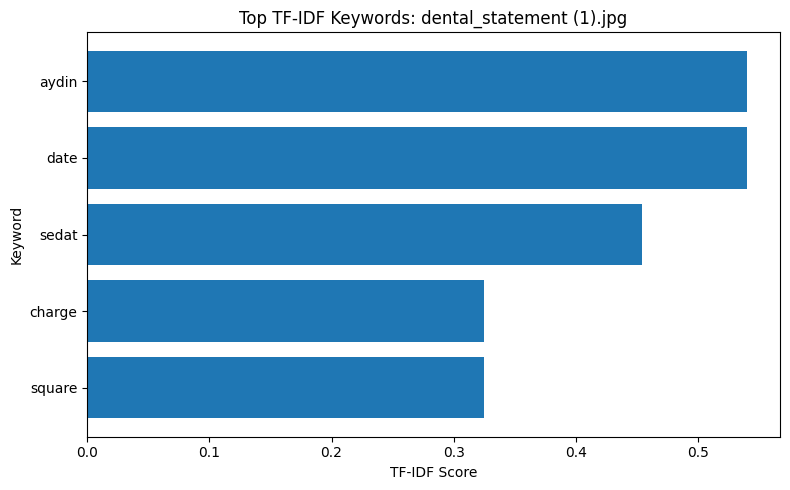

No TF-IDF keywords available for pharmacy_receipt (1).jpg


In [23]:
# ============================================================
# Step 7f: Visualise improved TF-IDF keywords
# ============================================================
# I create a bar chart for each document to show the top TF-IDF keywords visually.

for doc_name, keywords in improved_tfidf_results.items():

    if len(keywords) == 0:
        print(f"No TF-IDF keywords available for {doc_name}")
        continue

    terms = [item[0] for item in keywords]
    scores = [item[1] for item in keywords]

    plt.figure(figsize=(8, 5))
    plt.barh(terms, scores)
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Keyword")
    plt.title(f"Top TF-IDF Keywords: {doc_name}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### TF-IDF Observation

The improved TF-IDF results provide more meaningful keywords for most documents.

For example, the academic poster contains research-related terms such as "depression", "study", and "group", while the booking form includes terms like "booking", "bed", and "property".

However, some limitations are still visible. In certain documents such as the pharmacy receipt, no strong keywords were identified. This is likely due to the short length of the text and the presence of mostly numerical or repetitive information.

Similarly, in the dental invoice, numerical values such as "12000" appear as important features. This shows that TF-IDF can sometimes assign high importance to numeric tokens when the dataset is small.

Overall, this step demonstrates both the strengths and limitations of TF-IDF when applied to small and heterogeneous document sets.

## Step 8: Document Type Classification

In this step, I classify each document based on the extracted keywords.

The classification is rule-based and uses the presence of specific keywords to determine the document type.

In [30]:
# ============================================================
# Step 8a: Document classification function
# ============================================================
# I classify each document using simple keyword rules.

def classify_document(tokens):

    text = " ".join(tokens)

    if "pharmacy" in text or "visa" in text or "sale" in text:
        return "Receipt"

    elif "booking" in text or "reservation" in text:
        return "Booking Document"

    elif "invoice" in text or "account" in text or "statement" in text:
        return "Financial Document"

    elif "study" in text or "university" in text or "research" in text:
        return "Academic Document"

    else:
        return "Unknown"

In [31]:
# ============================================================
# Step 8b: Apply classification
# ============================================================
# I apply the classification function to all documents.

document_types = {}

for image_name, tokens in nlp_results.items():
    doc_type = classify_document(tokens)
    document_types[image_name] = doc_type

print("Document classification completed.")

Document classification completed.


In [32]:
# ============================================================
# Step 8c: Display classification results
# ============================================================
# I display the predicted document type for each image.

for image_name, doc_type in document_types.items():
    print(f"{image_name} → {doc_type}")

academic_poster (1).jpg → Academic Document
booking_form (1).jpg → Booking Document
dental_invoice (1).jpg → Financial Document
dental_statement (1).jpg → Financial Document
pharmacy_receipt (1).jpg → Receipt


### Classification Approach

A rule-based classification approach was used because the dataset is small and the main goal of the assignment is to demonstrate the full document processing pipeline rather than train a machine learning model.

### Document Classification Observation

The rule-based classification successfully identified the different types of documents.

The academic poster was correctly classified as an academic document, while the booking form and financial records were grouped into appropriate categories.

The pharmacy receipt was also correctly identified due to the presence of keywords such as "visa" and "sale".

Although this approach is simple, it demonstrates how NLP features can be used to distinguish between document types.

However, the method relies heavily on keyword presence and may not generalise well to unseen documents. More advanced models could improve classification performance.

## Step 9: Visual Feature Detection

In this step, I apply basic computer vision techniques to detect visual regions in each document.

The goal is to identify structural elements such as text blocks, tables, and layout regions using contour detection.

In [33]:
# ============================================================
# Step 9a: Detect visual regions using filtered contours
# ============================================================
# I use contour detection to find larger visual regions in each document.
# Small contours are filtered out so that the output focuses on meaningful layout areas instead of noise.

def detect_visual_regions(image_path):

    image = cv2.imread(image_path)
    original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Create a binary image for contour detection
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

    # Find contours in the thresholded image
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    output = original.copy()
    valid_contours = 0

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Filter out small noise and keep larger layout regions
        if w > 100 and h > 50:
            cv2.rectangle(output, (x, y), (x+w, y+h), (255, 0, 0), 2)
            valid_contours += 1

    return original, output, valid_contours

Visual regions detected in: academic_poster (1).jpg
Total contours found: 11


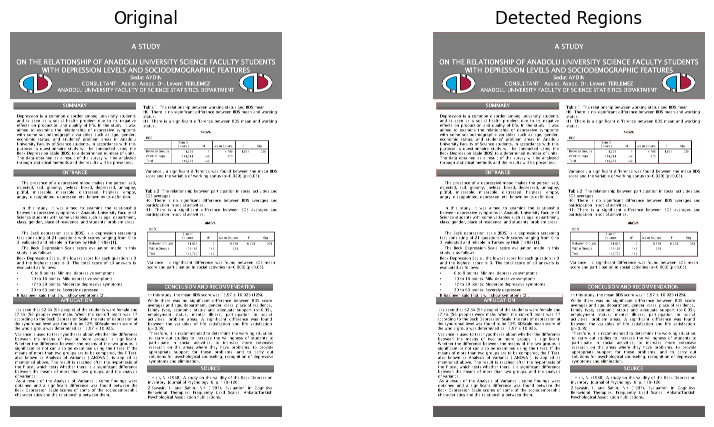

Visual regions detected in: booking_form (1).jpg
Total contours found: 1


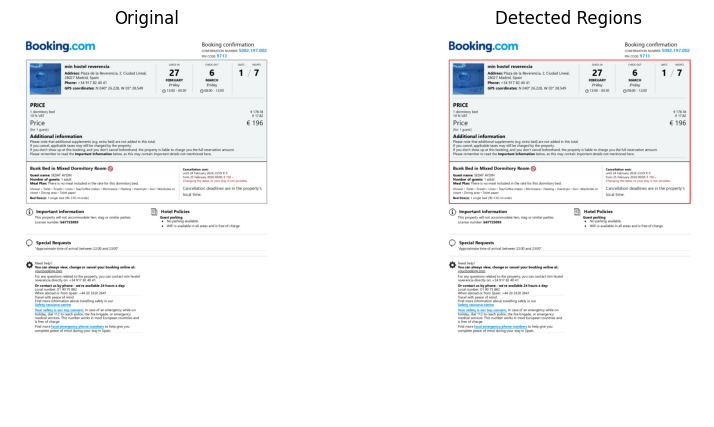

Visual regions detected in: dental_invoice (1).jpg
Total contours found: 0


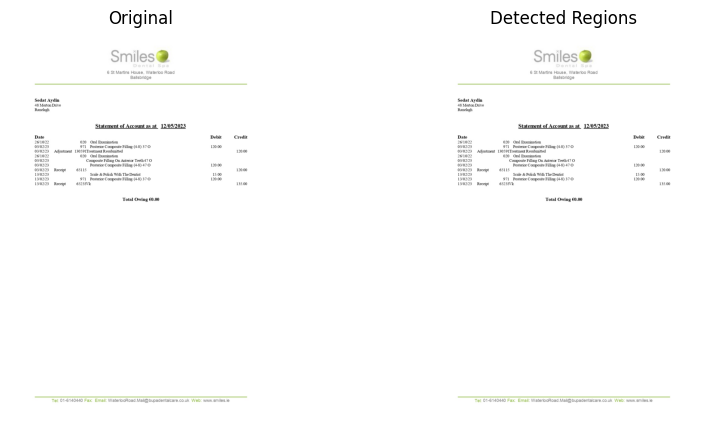

Visual regions detected in: dental_statement (1).jpg
Total contours found: 0


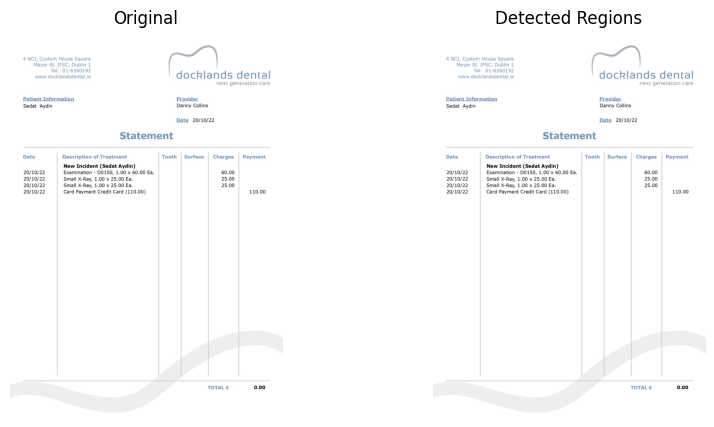

Visual regions detected in: pharmacy_receipt (1).jpg
Total contours found: 0


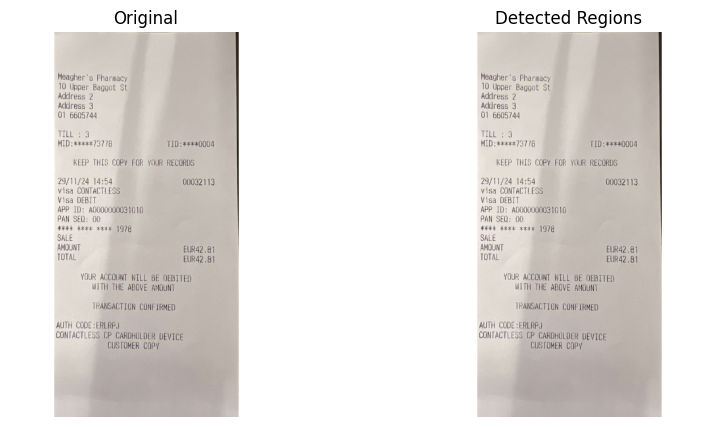

In [34]:
# ============================================================
# Step 9b: Apply visual detection to all images
# ============================================================
# I apply contour detection to each document and display the results.

for image_name in image_names:

    original, detected, count = detect_visual_regions(image_name)

    print("=" * 50)
    print(f"Visual regions detected in: {image_name}")
    print(f"Total contours found: {count}")

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(detected)
    plt.title("Detected Regions")
    plt.axis("off")

    plt.show()

### Visual Feature Detection Observation

In this step, contour detection was used to identify visual regions in each document.

After filtering small contours, the results focused more on larger structural areas such as text blocks and layout sections.

The method worked well for documents with clear structure, such as forms, while it was less precise for dense text-heavy documents.

This shows that basic computer vision techniques can support document analysis, but more advanced methods would be needed for highly accurate layout detection.

This approach is quite basic and mainly highlights larger regions. More advanced methods would be needed for precise layout detection.

## Step 10: Multi-modal Summary

In this step, I summarise the results from the OCR, NLP and visual analysis for each document.

This provides a combined overview of the extracted text, key features and document type.

In [37]:
# ============================================================
# Step 10: Create final summary table
# ============================================================
# I combine OCR, NLP, TF-IDF and classification results into a structured summary.

summary_data = []

for doc_name in document_names:

    ocr_text = ocr_results.get(doc_name, "")
    tokens = nlp_results.get(doc_name, [])
    keywords = improved_tfidf_results.get(doc_name, [])
    doc_type = document_types.get(doc_name, "Unknown")

    summary_data.append({
        "Document": doc_name,
        "Type": doc_type,
        "OCR Text Length": len(ocr_text),
        "Token Count": len(tokens),
       "Top Keywords": ", ".join([k[0] for k in keywords[:5]]) if keywords else "No keywords extracted"
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Document,Type,OCR Text Length,Token Count,Top Keywords
0,academic_poster (1).jpg,Academic Document,5381,467,"mean, bd, difference, significant, depression"
1,booking_form (1).jpg,Booking Document,2437,249,"bed, property, number, booking, charge"
2,dental_invoice (1).jpg,Financial Document,637,77,"12000, scale, date, sedat"
3,dental_statement (1).jpg,Financial Document,490,48,"aydin, date, sedat, charge, square"
4,pharmacy_receipt (1).jpg,Receipt,434,48,No keywords extracted


### Summary Observation

The summary table combines the outputs from OCR, NLP, TF-IDF and document classification into a single structured view.

Clear differences can be observed between document types. The academic poster contains a large amount of text and meaningful keywords, while structured documents such as invoices and statements are shorter and contain more numerical information.

The booking form shows a mix of descriptive and structured content, which is reflected in its keywords.

The pharmacy receipt produced no strong keywords. This is likely due to its limited text variety, numerical dominance and OCR noise, which affected the TF-IDF results.

Overall, this step demonstrates how combining multiple techniques provides a more complete understanding of different document types.

## Step 11: Final Conclusion

In this project, I built a simple document processing pipeline using both computer vision and NLP techniques.

I worked with different types of documents, including an academic poster, a booking form, financial documents and a receipt. Even though the same pipeline was applied to all of them, the results were quite different depending on the document type.

I noticed that OCR works much better on clean and well-structured documents. For example, the academic poster and booking form produced clearer text, while the receipt required extra preprocessing because of lighting issues.

After OCR, the NLP steps helped to extract useful tokens, but errors from OCR sometimes affected the results. TF-IDF worked well for longer documents with more text, but it was less effective for short or number-heavy documents.

The document classification step worked as expected, and the visual detection step gave a basic idea of document layout, although it is not very precise.

Overall, this project showed me how OCR, NLP and simple computer vision methods can be combined to analyse documents. At the same time, it also showed the limitations of these methods, especially when working with noisy or unstructured data.